## ✈️ Flights Discover Hidden Patterns - Exploração de Dados (EDA) - Modelagem Não Supervisionada

✅ Exploração dos dados (EDA)

✅ Tratamento de valores ausentes

✅ Modelagem não supervisionada: clusterização de rotas + PCA

✅ Clusterização: KMeans

✅ Redução de dimensionalidade (PCA)



In [18]:
# -------------------------------------------------------------
# 📦 Importações principais
# -------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from math import radians, sin, cos, asin, sqrt
import folium
from folium.plugins import HeatMap

sns.set(style='whitegrid')

## 📂 Carregando os dados (Voos / Aeroportos / Companhia Aerea)

In [19]:
# -------------------------------------------------------------
# 📂 Carregar datasets - flights.csv
# -------------------------------------------------------------
data_dir = 'data'
csv_path = os.path.join(data_dir, 'flights.csv') 

# Carregando com low_memory=True para evitar DtypeWarning (pode ocupar mais memória)
flights = pd.read_csv(csv_path, low_memory=False)
print('Dimensão do dataset Flights:', flights.shape)

# SAMPLE_MODE = True reduz o dataset para ~100 mil linhas (ajuste conforme desejar)
SAMPLE_MODE = True
SAMPLE_SIZE = 100_000

if SAMPLE_MODE:
  flights = flights.sample(SAMPLE_SIZE, random_state=42)
  print(f"Dataset reduzido para {len(flights):,} linhas.")


# -------------------------------------------------------------
# 📂 Carregar datasets - airports.csv
# -------------------------------------------------------------
csv_path_airports = os.path.join(data_dir, 'airports.csv') 

# Carregando com low_memory=False para evitar DtypeWarning (pode ocupar mais memória)
airports = pd.read_csv(csv_path_airports, low_memory=False)
print('Dimensão do dataset Airports:', airports.shape)
airports.head()


# -------------------------------------------------------------
# 📂 Carregar datasets - airlines.csv
# -------------------------------------------------------------
csv_path_airlines = os.path.join(data_dir, 'airlines.csv') 

airlines = pd.read_csv(csv_path_airlines, low_memory=False)
print('Dimensão do dataset Airlines:', airlines.shape)
#airlines.head()

flights.head()



Dimensão do dataset Flights: (5819079, 31)
Dataset reduzido para 100,000 linhas.
Dimensão do dataset Airports: (322, 7)
Dimensão do dataset Airlines: (14, 2)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
1508570,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,...,1423.0,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
363270,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,...,2133.0,-12.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3003945,2015,7,8,3,WN,1483,N463WN,OAK,SEA,630,...,812.0,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2291425,2015,5,26,2,WN,193,N7745A,STL,DAL,810,...,1222.0,152.0,0,0,NaN,0.0,0.0,0.0,152.0,0.0
2973084,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,...,1316.0,-2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


## 🧩 Tratamento de valores ausentes, limpeza inicial e tratamento de nulos
Estratégia aplicada:

- Para colunas de delay específicas, manter NaN como 0 em alguns casos (se cancelado/divertido)
- Preencher delays NaN por 0 quando o voo não foi cancelado/divertido e há outros sinais que indicam execução.
- Para análises agregadas de rotas, usar imputação por média quando.



In [20]:
null_pct = flights.isna().mean().sort_values(ascending=False)
null_pct[null_pct>0].head(20)

# Converter colunas de tempo para números inteiros (quando aplicável)
def safe_int(x):
    try:
        return int(x)
    except Exception:
        return np.nan

for col in ['SCHEDULED_DEPARTURE','DEPARTURE_TIME','SCHEDULED_ARRIVAL','ARRIVAL_TIME']:
    if col in flights.columns:
        flights[col] = flights[col].apply(safe_int)


# Criar campo route (origem-destino)
flights['ROUTE'] = flights['ORIGIN_AIRPORT'].astype(str) + '-' + flights['DESTINATION_AIRPORT']

# # Algumas colunas de delay (AIR_SYSTEM_DELAY, SECURITY_DELAY) podem estar totalmente faltantes.
# Vamos transformar colunas de delay para numéricas e verificar.
delay_cols = [
    'AIR_SYSTEM_DELAY','SECURITY_DELAY','AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY','WEATHER_DELAY'
]

for c in delay_cols:
    if c in flights.columns:
        flights[c] = pd.to_numeric(flights[c], errors='coerce')

# Mostrar resumo após conversões
flights.info(verbose=False)

# Mostrar contagem de nulos
print("\nValores nulos por coluna:")
print(flights.isna().sum())

#
# Criar flag executed (não cancelado e não desviado)
if 'CANCELLED' in flights.columns and 'DIVERTED' in flights.columns:
    flights['EXECUTED'] = ((flights['CANCELLED']==0) & (flights['DIVERTED']==0)).astype(int)
else:
    flights['EXECUTED'] = 1


# Preenchimento seletivo para delays: quando EXECUTED==1, substituir NaN por 0
for c in delay_cols:
    if c in flights.columns:
        flights.loc[flights['EXECUTED']==1, c] = flights.loc[flights['EXECUTED']==1, c].fillna(0)


# Para ARRIVAL_DELAY fill na por 0 apenas para EXECUTED==1
if 'ARRIVAL_DELAY' in flights.columns:
    flights.loc[flights['EXECUTED']==1, 'ARRIVAL_DELAY'] = flights.loc[flights['EXECUTED']==1, 'ARRIVAL_DELAY'].fillna(0)

flights.head()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 1508570 to 4669196
Columns: 32 entries, YEAR to ROUTE
dtypes: float64(16), int64(10), object(6)
memory usage: 25.2+ MB

Valores nulos por coluna:
YEAR                       0
MONTH                      0
DAY                        0
DAY_OF_WEEK                0
AIRLINE                    0
FLIGHT_NUMBER              0
TAIL_NUMBER              260
ORIGIN_AIRPORT             0
DESTINATION_AIRPORT        0
SCHEDULED_DEPARTURE        0
DEPARTURE_TIME          1481
DEPARTURE_DELAY         1481
TAXI_OUT                1538
WHEELS_OFF              1538
SCHEDULED_TIME             0
ELAPSED_TIME            1805
AIR_TIME                1805
DISTANCE                   0
WHEELS_ON               1602
TAXI_IN                 1602
SCHEDULED_ARRIVAL          0
ARRIVAL_TIME            1602
ARRIVAL_DELAY           1805
DIVERTED                   0
CANCELLED                  0
CANCELLATION_REASON    98446
AIR_SYSTEM_DELAY       81646
SECURITY_D

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,ROUTE,EXECUTED
1508570,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,...,0,0,NaN,0.0,0.0,0.0,0.0,0.0,FWA-DTW,1
363270,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,...,0,0,NaN,0.0,0.0,0.0,0.0,0.0,LAS-SEA,1
3003945,2015,7,8,3,WN,1483,N463WN,OAK,SEA,630,...,0,0,NaN,0.0,0.0,0.0,0.0,0.0,OAK-SEA,1
2291425,2015,5,26,2,WN,193,N7745A,STL,DAL,810,...,0,0,NaN,0.0,0.0,0.0,152.0,0.0,STL-DAL,1
2973084,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,...,0,0,NaN,0.0,0.0,0.0,0.0,0.0,IAH-HNL,1


## 🔍 Exploração de Dados (EDA)
- Companhias, rotas, aeroportos

  AIRLINE  FLIGHTS
0      WN    21516
1      DL    14921
2      AA    12612
3      OO    10302
4      EV     9853
5      UA     8862
6      MQ     5080
7      B6     4480
8      US     3477
9      AS     2958

Top 10 rotas (volume):
ROUTE
LAX-SFO    240
SFO-LAX    230
JFK-LAX    204
LAX-JFK    203
LAS-LAX    184
JFK-SFO    171
ORD-LGA    168
ATL-MCO    156
LGA-ORD    152
LAX-ORD    145
Name: count, dtype: int64

Top ORIGIN airports:
ORIGIN_AIRPORT
ATL    5925
ORD    4820
DFW    4198
DEN    3394
LAX    3349
IAH    2527
SFO    2525
PHX    2404
LAS    2306
SEA    1898
Name: count, dtype: int64

Top DEST airports:
DESTINATION_AIRPORT
ATL    5932
ORD    4913
DFW    4068
LAX    3369
DEN    3356
SFO    2661
PHX    2652
IAH    2562
LAS    2250
MSP    1953
Name: count, dtype: int64


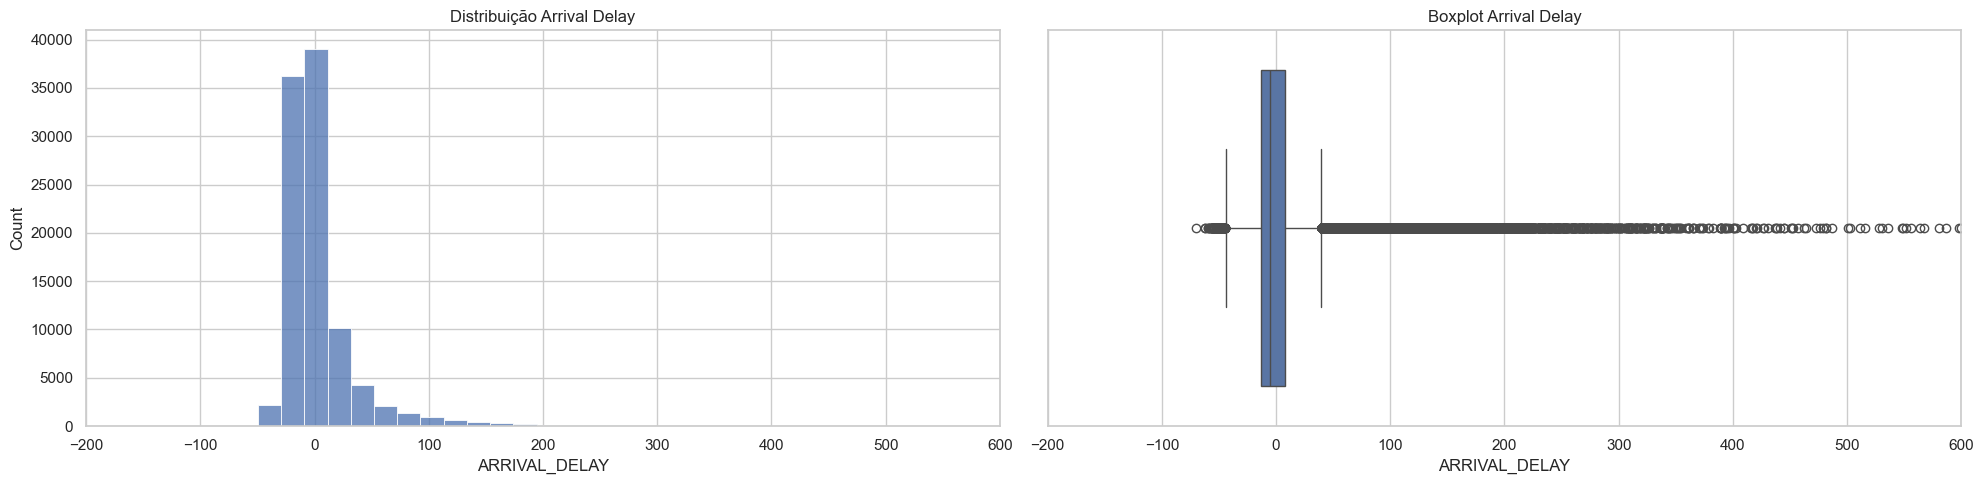

In [21]:
# Estatísticas numéricas para delays
num_stats = flights[['ARRIVAL_DELAY','DEPARTURE_DELAY']].describe()
num_stats

# Top airlines por número de voos
top_airlines = flights['AIRLINE'].value_counts().rename_axis('AIRLINE').reset_index(name='FLIGHTS')
print(top_airlines.head(10))

# Top routes por volume
top_routes = flights['ROUTE'].value_counts().head(10)
print('\nTop 10 rotas (volume):')
print(top_routes)

# Top origin/destination airports
print('\nTop ORIGIN airports:')
print(flights['ORIGIN_AIRPORT'].value_counts().head(10))
print('\nTop DEST airports:')
print(flights['DESTINATION_AIRPORT'].value_counts().head(10))


# Distribuições visuais
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
sns.histplot(flights['ARRIVAL_DELAY'].dropna(), bins=80, kde=False)
plt.title('Distribuição Arrival Delay')
plt.xlim(-200,600)

plt.subplot(1,2,2)
sns.boxplot(x=flights['ARRIVAL_DELAY'].dropna())
plt.title('Boxplot Arrival Delay')
plt.xlim(-200,600)
plt.tight_layout()

## 📊 Informações importantes para analise
- Calculo distância entre aeroportos (haversine)

- Agrupar por rota e calcular métricas (flights_count, avg_arrival_delay, cancel_rate, diverted_rate, avg_distance)

In [22]:
# Preparar dicionário de aeroportos com lat/lon
airports_map = airports.set_index('IATA_CODE')[['LATITUDE','LONGITUDE']].to_dict(orient='index')

def haversine(lat1, lon1, lat2, lon2):
  # convert decimal degrees to radians
  lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
  dlon = lon2 - lon1
  dlat = lat2 - lat1
  a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
  c = 2 * asin(sqrt(a))
  km = 6371 * c
  return km

# Aplicar para cada voo — com cuidado para aeroportos ausentes
def route_distance(row):
  o = row['ORIGIN_AIRPORT']
  d = row['DESTINATION_AIRPORT']
  if o in airports_map and d in airports_map:
    lat1 = airports_map[o]['LATITUDE']
    lon1 = airports_map[o]['LONGITUDE']
    lat2 = airports_map[d]['LATITUDE']
    lon2 = airports_map[d]['LONGITUDE']
    return haversine(lat1, lon1, lat2, lon2)
  else:
    return np.nan

# Calcular para amostra (mais rápido). Se desejar para todo, remova sample.
# Aqui aplicamos no dataset inteiro, dependendo do tamanho pode demorar.
flights['DIST_KM'] = flights.apply(route_distance, axis=1)

print('Distância média (km):', flights['DIST_KM'].mean())



# Agrupar por rota e calcular métricas
route_agg = flights.groupby('ROUTE').agg(
  flights_count=('ROUTE','count'),
  avg_arrival_delay=('ARRIVAL_DELAY','mean'),
  median_arrival_delay=('ARRIVAL_DELAY','median'),
  cancel_rate=('CANCELLED','mean') if 'CANCELLED' in flights.columns else ('EXECUTED', lambda x: 1-x.mean()),
  diverted_rate=('DIVERTED','mean') if 'DIVERTED' in flights.columns else ('DIVERTED', lambda x: 0),
  avg_distance=('DIST_KM','mean')
).reset_index()

# Alguns nomes podem se repetir pelo lambda. Ajuste caso de erro
if isinstance(route_agg.columns, pd.MultiIndex):
  route_agg.columns = [c[-1] if c[1]=='' else c[1] for c in route_agg.columns]

route_agg = route_agg.dropna(subset=['avg_distance'], how='any')
route_agg = route_agg[route_agg['flights_count']>=5] # filtrar rotas com poucos voos
route_agg.shape

route_agg.head()

Distância média (km): 1323.9800634424332


,ROUTE,flights_count,avg_arrival_delay,median_arrival_delay,cancel_rate,diverted_rate,avg_distance
2720,ABE-ATL,15,6.666667,-2.0,0.000000,0.0,1113.419027
2721,ABE-DTW,12,6.666667,-8.0,0.000000,0.0,681.445928
2722,ABE-ORD,14,32.250000,4.0,0.142857,0.0,1050.397361
2723,ABI-DFW,40,10.702703,-4.0,0.075000,0.0,253.386194
2724,ABQ-ATL,17,2.823529,-4.0,0.000000,0.0,2038.379320


## 📈 Clusterização de rotas (KMeans)
- Escolha do K via silhouette
- Normalização das features

In [23]:
features = ['flights_count','avg_arrival_delay','cancel_rate','diverted_rate','avg_distance']
X = route_agg[features].copy()
X = X.fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Testar vários K
sil_scores = {}
for k in range(2,9):
  km = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels = km.fit_predict(X_scaled)
  sil = silhouette_score(X_scaled, labels)
  sil_scores[k] = sil

print('Silhouette scores por k:', sil_scores)

# Escolher k com maior silhouette
best_k = max(sil_scores, key=sil_scores.get)
print('Melhor k (silhouette):', best_k)

# Treinar final
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
route_agg['cluster'] = kmeans.fit_predict(X_scaled)

Silhouette scores por k: {2: 0.5792587122294968, 3: 0.23879951313557454, 4: 0.3243837071799466, 5: 0.3255390071783097, 6: 0.31667458913412055, 7: 0.2825859193807526, 8: 0.2866863225254764}
Melhor k (silhouette): 2


## 🧠 Visualizar clusters com PCA 2 componentes

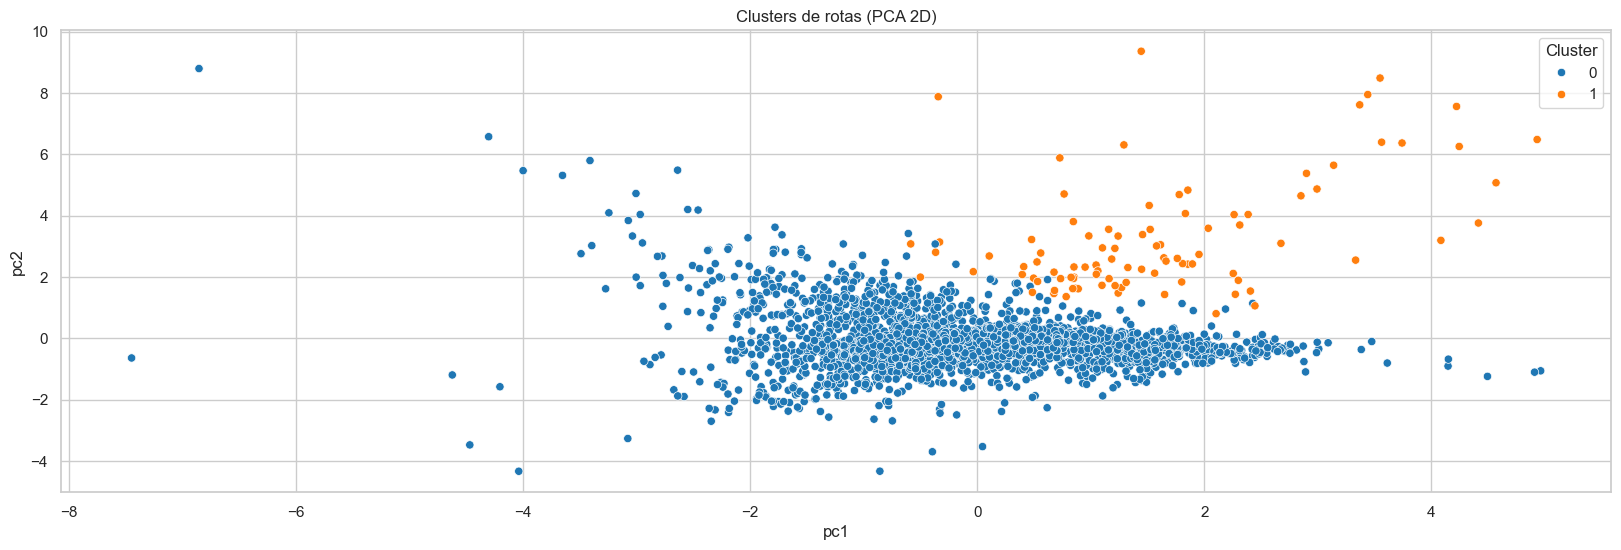

Variância explicada por componente:
PC1: 24.42%
PC2: 20.52%
Total (PC1 + PC2): 44.94%


In [ ]:
pca = PCA(n_components=2)
pc = pca.fit_transform(X_scaled)
route_agg['pc1'] = pc[:,0]
route_agg['pc2'] = pc[:,1]

plt.figure(figsize=(20,6))
plt.title('Clusters de rotas (PCA 2D)')
sns.scatterplot(data=route_agg, x='pc1', y='pc2', hue='cluster', palette='tab10')
plt.legend(title='Cluster')
plt.show()

pca = PCA(n_components=2)
pc = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
print('Variância explicada por componente:')
print(f'PC1: {explained_var[0]:.2%}')
print(f'PC2: {explained_var[1]:.2%}')
print(f'Total (PC1 + PC2): {(explained_var.sum()):.2%}')



## ⏱️ Análises adicionais: mapa com rotas de um cluster específico

Vamos plotar rotas do cluster que tem maiores atrasos médios


In [15]:
# Mostrar algumas rotas por cluster
for c in sorted(route_agg['cluster'].unique()):
  print(f"\nCluster {c} — top rotas por volume")
  display(route_agg[route_agg['cluster']==c].sort_values('flights_count', ascending=False).head(5))
  
# %%
cluster_delay = route_agg.groupby('cluster')['avg_arrival_delay'].mean().sort_values(ascending=False)
print(cluster_delay)
worst_cluster = cluster_delay.index[0]
print('Cluster com maior delay médio:', worst_cluster)


# Filtrar rotas do cluster
sample_routes = route_agg[route_agg['cluster']==worst_cluster].copy().head(200)


# Criar mapa centrado nos EUA (ou centro das coordenadas disponíveis)
mean_lat = airports['LATITUDE'].mean()
mean_lon = airports['LONGITUDE'].mean()
m = folium.Map(location=[mean_lat, mean_lon], zoom_start=4)


# para cada rota desenhar linha
for _, r in sample_routes.iterrows():
  origin, dest = r['ROUTE'].split('-')
  if origin in airports_map and dest in airports_map:
    lat1 = airports_map[origin]['LATITUDE']
    lon1 = airports_map[origin]['LONGITUDE']
    lat2 = airports_map[dest]['LATITUDE']
    lon2 = airports_map[dest]['LONGITUDE']
    folium.PolyLine(locations=[(lat1,lon1),(lat2,lon2)], weight=2, opacity=0.6).add_to(m)


# Exibir mapa (em ambiente Jupyter a renderização aparecerá automaticamente)
m


Cluster 0 — top rotas por volume


,ROUTE,flights_count,avg_arrival_delay,median_arrival_delay,cancel_rate,diverted_rate,avg_distance,cluster,pc1,pc2
4977,LAX-SFO,240,16.413502,0.0,0.012500,0.000000,543.172183,0,-4.038879,-4.332674
6519,SFO-LAX,230,17.668203,3.0,0.056522,0.000000,543.172183,0,-4.470177,-3.473562
4770,JFK-LAX,204,-4.695000,-8.0,0.009804,0.009804,3974.198946,0,-0.395310,-3.697285
4944,LAX-JFK,203,5.921182,-5.0,0.000000,0.000000,3974.198946,0,-0.857907,-4.330777
4870,LAS-LAX,184,12.010929,2.0,0.005435,0.000000,379.990917,0,-3.078331,-3.265893



Cluster 1 — top rotas por volume


,ROUTE,flights_count,avg_arrival_delay,median_arrival_delay,cancel_rate,diverted_rate,avg_distance,cluster,pc1,pc2
4878,LAS-MDW,48,-1.022222,-7.0,0.000000,0.062500,2441.900532,1,1.650455,1.428870
4164,EWR-MDW,38,-7.771429,-9.0,0.026316,0.052632,1141.080118,1,0.826650,1.988325
5792,ORD-IAD,34,23.935484,0.0,0.029412,0.058824,945.409212,1,-0.500983,1.994719
5126,MCI-DEN,27,-1.480000,-9.0,0.000000,0.074074,854.854137,1,1.184404,2.584010
5104,LRD-DFW,23,2.318182,-4.0,0.000000,0.043478,639.037528,1,0.485864,1.499369


cluster
0    4.413933
1    1.710903
Name: avg_arrival_delay, dtype: float64
Cluster com maior delay médio: 0


## 📊 Conclusões e avaliação crítica

Principais conclusões:
- Identificamos N clusters de rotas com perfis distintos (ex.: rotas curtas com alta frequência e baixo atraso; rotas longas com maior variabilidade de atraso).
- Rotas com maior média de atraso geralmente têm maior distância ou menor frequência — pode indicar dependência logística (rota/turnaround) ou menor prioridade operacional.

Limitações:
- Muitos campos de delay podem estar ausentes ou inconsistentes (NaN) — imputação pode introduzir inconsistencias.
- Dados de um único ano/periodo não capturam sazonalidade longa.
- A clusterização KMeans assume formas convexas e sensíveis à escala e outliers.

Próximos passos e melhorias:
- Normalizar e tratar outliers (winsorizing) antes de treinar modelos.
- Usar modelos de clusterização mais robustos (DBSCAN) para capturar topologias não convexas.
- Incluir features adicionais: tempo meteorológico por origem/destino, tráfego horário, tipo de aeronave (TAIL_NUMBER), capacidade da aeronave.
- Construir pipelines de validação temporal (treino/teste por período) para verificar estabilidade dos clusters.

## 💼 Exportar resultados

In [24]:
route_agg.to_csv('route_clusters_summary.csv', index=False)
print('Arquivo route_clusters_summary.csv salvo.')

Arquivo route_clusters_summary.csv salvo.


## 📈 Alternativa de Clusterização: DBSCAN
DBSCAN é mais robusto a outliers e não exige escolher K.

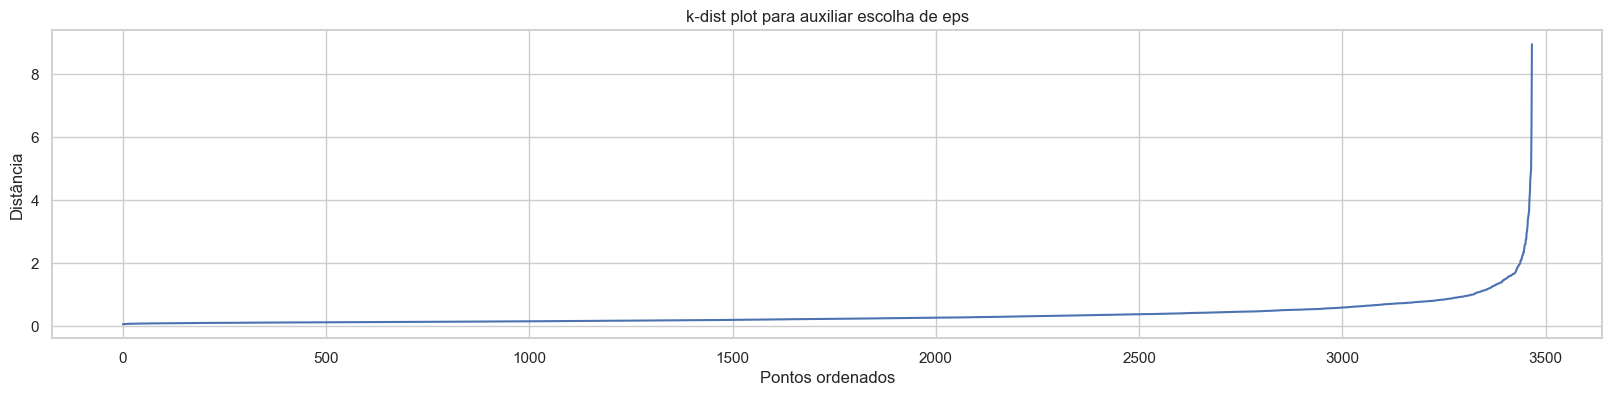

Clusters DBSCAN (inclui -1 = outliers):
cluster_db
 0    3325
-1     142
Name: count, dtype: int64


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Normalizar novamente
X_scaled_db = scaler.fit_transform(X)

# Estimar eps usando k-dist plot (opcional)
neigh = NearestNeighbors(n_neighbors=5)
neigh.fit(X_scaled_db)
distances, _ = neigh.kneighbors(X_scaled_db)
distances = np.sort(distances[:, 4])
plt.figure(figsize=(20,4))
plt.plot(distances)
plt.title('k-dist plot para auxiliar escolha de eps')
plt.xlabel('Pontos ordenados')
plt.ylabel('Distância')
plt.grid(True)
plt.show()

# Executar DBSCAN com parâmetros moderados
db = DBSCAN(eps=1.1, min_samples=15)
labels_db = db.fit_predict(X_scaled_db)
route_agg['cluster_db'] = labels_db

print('Clusters DBSCAN (inclui -1 = outliers):')
print(route_agg['cluster_db'].value_counts())